<a href="https://colab.research.google.com/github/Skaims/DLAV/blob/main/DLAV_Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DLAV Project - Phase 3

In this notebook we will train a very simple planner and test its real-world performance.


The first step is to prepare the data. The code below will download the data from google drive and extract it here for your code to use. Whenever your session gets restarted, remember to re-run this cell to re-download the data.

In [1]:
# Install gdown to handle Google Drive file download
!pip install -q gdown

import gdown
import zipfile

download_url = f"https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr"
output_zip = "dlav_train.zip"
gdown.download(download_url, output_zip, quiet=False)  # Downloads the file to your drive
with zipfile.ZipFile(output_zip, 'r') as zip_ref:  # Extracts the downloaded zip file
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=17DREGym_-v23f_qbkMHr7vJstbuTt0if"
output_zip = "dlav_val_real.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1_l6cui0pCJ_caixN0uTkkUOfu6ICO8u5"
output_zip = "test_public_real.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

Downloading...
From (original): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr
From (redirected): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr&confirm=t&uuid=0a1b878b-547a-43bc-979a-19db1cad26df
To: /content/dlav_train.zip
100%|██████████| 439M/439M [00:04<00:00, 96.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=17DREGym_-v23f_qbkMHr7vJstbuTt0if
From (redirected): https://drive.google.com/uc?id=17DREGym_-v23f_qbkMHr7vJstbuTt0if&confirm=t&uuid=9d05d1e7-8bd5-4f2f-8c29-3dc3a83a9c7a
To: /content/dlav_val_real.zip
100%|██████████| 129M/129M [00:04<00:00, 30.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1_l6cui0pCJ_caixN0uTkkUOfu6ICO8u5
From (redirected): https://drive.google.com/uc?id=1_l6cui0pCJ_caixN0uTkkUOfu6ICO8u5&confirm=t&uuid=1fad21e1-365f-4baf-8ced-56b22eeb391d
To: /content/test_public_real.zip
100%|██████████| 110M/110M [00:03<00:00, 36.4MB/s] 


Now lets load the data and visualize how the real data looks like!

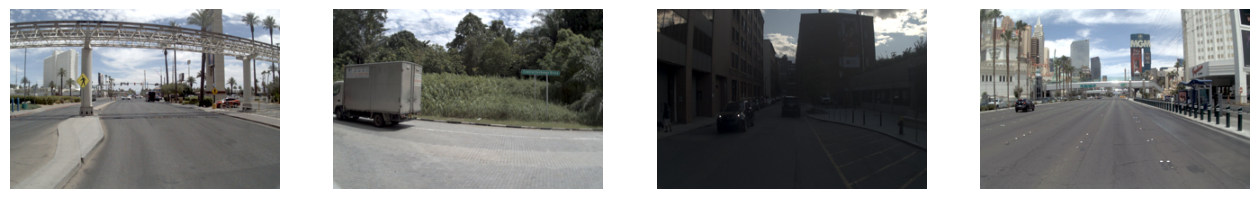

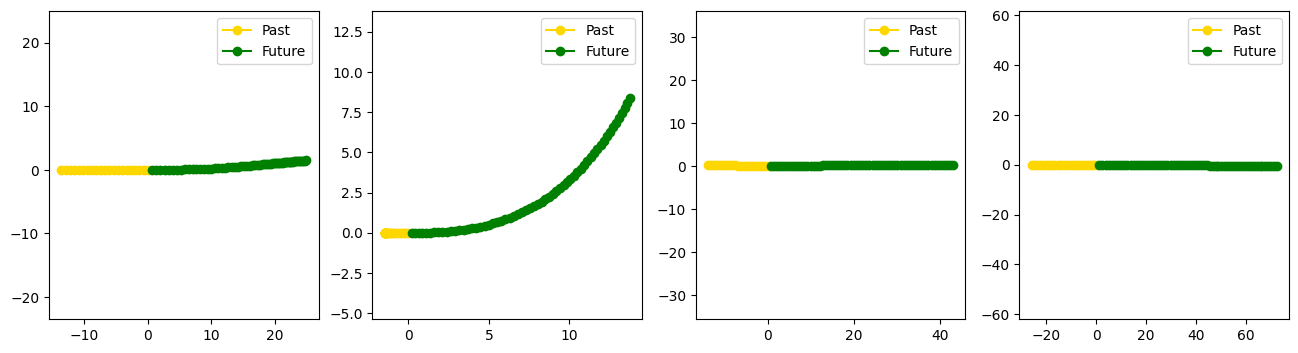

In [2]:

import pickle
import matplotlib.pyplot as plt
import numpy as np
import random
import os
k = 4
# load the data
data = []
test_files = os.listdir("val_real")

for i in range(k):
    with open(f"val_real/{test_files[i]}", "rb") as f:
        data.append(pickle.load(f))

# plot the camera view of current step for the k examples
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].imshow(data[i]["camera"])
    axis[i].axis("off")
plt.show()

# plot the past and future trajectory of the vehicle
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].plot(data[i]["sdc_history_feature"][:, 0], data[i]["sdc_history_feature"][:, 1], "o-", color="gold", label="Past")
    axis[i].plot(data[i]["sdc_future_feature"][:, 0], data[i]["sdc_future_feature"][:, 1], "o-", color="green", label="Future")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

Now let's train the model with synthetic data and test it with the real-world data.

In [5]:
import os
import math
import random
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import copy

class DrivingDataset(Dataset):
    def __init__(self, file_list, test=False, augment=False):
        self.samples = file_list
        self.test = test
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        with open(self.samples[idx], 'rb') as f:
            data = pickle.load(f)

        camera = torch.from_numpy(data['camera']).permute(2, 0, 1).float() / 255.0
        history = torch.tensor(data['sdc_history_feature'], dtype=torch.float32)
        future = None if self.test else torch.tensor(data['sdc_future_feature'], dtype=torch.float32)

        # Center around the last history point
        last_pos = history[-1, :2].clone()
        history[:, :2] -= last_pos
        if future is not None:
            future[:, :2] -= last_pos

        if self.augment and not self.test:
            camera, history, future = self._augment(
                camera, history, future
            )

        out = {'camera': camera, 'history': history}
        if not self.test:
            out['future'] = future
        return out

    def _augment(self, camera, depth, seg, history, future):
        # Horizontal flip
        if random.random() < 0.5:
            camera = TF.hflip(camera)
            history[:, 0] = -history[:, 0]
            if future is not None:
                future[:, 0] = -future[:, 0]

        # ColorJitter on camera only
        if random.random() < 0.8:
            camera = TF.adjust_brightness(camera, 1.0 + random.uniform(-0.3, 0.3))
            camera = TF.adjust_contrast(camera,   1.0 + random.uniform(-0.3, 0.3))
            camera = TF.adjust_saturation(camera, 1.0 + random.uniform(-0.2, 0.2))
            camera = camera.clamp(0.0, 1.0)

        # Rotation ±5°
        if random.random() < 0.4:
            angle_deg = random.uniform(-5.0, 5.0)
            angle_rad = math.radians(angle_deg)
            cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)

            camera = TF.rotate(camera, angle_deg)

            # Rotation 2D of coordinates x,y (in-plane)
            def rotate_xy(pts):
                x, y = pts[:, 0].clone(), pts[:, 1].clone()
                pts[:, 0] =  cos_a * x + sin_a * y
                pts[:, 1] = -sin_a * x + cos_a * y
                return pts

            history = rotate_xy(history)
            if future is not None:
                future = rotate_xy(future)

        return camera, history, future


In [6]:
class Logger:
    def __init__(self):
        # Placeholder for potential future configs (e.g., log_dir, wandb_enabled, etc.)
        pass

    def log(self, step=None, **metrics):
        """
        Logs the given metrics.

        Args:
            step (int, optional): The current step or epoch. Useful for tracking.
            **metrics: Arbitrary keyword arguments representing metric names and values.
        """
        prefix = f"[Step {step}] " if step is not None else ""
        metric_str = " | ".join(f"{k}: {v}" for k, v in metrics.items())
        # print(prefix + metric_str)

Note: Replace with your own planner below

In [7]:
# FPN (Feature Pyramid Network)
class LightFPN(nn.Module):
    def __init__(self, feat_dim=256):
        super().__init__()
        self.lat4 = nn.Conv2d(512, feat_dim, 1)
        self.lat3 = nn.Conv2d(256, feat_dim, 1)
        self.lat2 = nn.Conv2d(128, feat_dim, 1)
        self.out = nn.Sequential(
            nn.Conv2d(feat_dim, feat_dim, 3, padding=1),
            nn.BatchNorm2d(feat_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, s2, s3, s4):
        p4 = self.lat4(s4)
        p4_up = F.interpolate(p4, size=s3.shape[2:], mode='nearest')
        p3 = self.lat3(s3) + p4_up
        p3_up = F.interpolate(p3, size=s2.shape[2:], mode='nearest')
        p2 = self.lat2(s2) + p3_up
        p2_dn = F.adaptive_avg_pool2d(p2, s3.shape[2:])
        return self.out(p3 + p2_dn)


# Queries
class WaypointQueryDecoder(nn.Module):
    def __init__(self, future_steps=60, future_dim=3,
                 d_model=256, nhead=8, num_layers=5,
                 feat_h=12, feat_w=18, dropout=0.05):
        super().__init__()
        self.future_steps = future_steps
        self.future_dim = future_dim

        self.waypoint_queries = nn.Embedding(future_steps, d_model)
        self.register_buffer('pos_enc', self._make_pos_enc(feat_h, feat_w, d_model))

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True,
            norm_first=True,
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.out_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(inplace=True),
            nn.Linear(d_model // 2, future_dim),
        )

    @staticmethod
    def _make_pos_enc(H, W, d_model):
        y_enc = torch.zeros(H, d_model // 2)
        x_enc = torch.zeros(W, d_model // 2)
        div = torch.exp(torch.arange(0, d_model // 2, 2).float()*(-(math.log(10000.0)/(d_model // 2))))
        y_pos = torch.arange(H).float().unsqueeze(1)
        x_pos = torch.arange(W).float().unsqueeze(1)
        y_enc[:, 0::2] = torch.sin(y_pos * div)
        y_enc[:, 1::2] = torch.cos(y_pos * div)
        x_enc[:, 0::2] = torch.sin(x_pos * div)
        x_enc[:, 1::2] = torch.cos(x_pos * div)
        pos = torch.cat([
            y_enc.unsqueeze(1).expand(H, W, d_model // 2),
            x_enc.unsqueeze(0).expand(H, W, d_model // 2),
        ], dim=-1)
        return pos.view(H * W, d_model)

    def forward(self, feat_map, context):
        B, C, H, W = feat_map.shape
        mem = feat_map.flatten(2).permute(0, 2, 1)

        if H * W != self.pos_enc.shape[0]:
            pos = F.interpolate(
                self.pos_enc.T.unsqueeze(0).unsqueeze(-1),
                size=(H * W, 1), mode='bilinear', align_corners=False
            ).squeeze().T
        else:
            pos = self.pos_enc
        mem = mem + pos.unsqueeze(0)

        queries = self.waypoint_queries.weight.unsqueeze(0).expand(B, -1, -1)
        queries = queries + context.unsqueeze(1)

        out = self.transformer_decoder(queries, mem)
        return self.out_head(out)

# Main Model
class PretrainedResNetPlannerCMD(nn.Module):
    def __init__(self,
                 history_steps: int = 21,
                 future_steps: int = 60,
                 history_dim: int = 3,
                 future_dim: int = 3,
                 backbone_pretrained: bool = True,
                 history_hidden: int = 128,
                 d_model: int = 256,
                 nhead: int = 8,
                 num_decoder_layers: int = 5,
                 dropout: float = 0.05,
                 num_seg_classes: int = 15,
                 feat_h: int = 12,
                 feat_w: int = 18):
        super().__init__()

        self.future_steps = future_steps
        self.future_dim = future_dim
        self.d_model = d_model

        resnet = models.resnet34(
            weights=models.ResNet34_Weights.IMAGENET1K_V1 if backbone_pretrained else None
        )
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        self.fpn = LightFPN(feat_dim=d_model)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.img_proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(inplace=True),
        )

        self.history_gru = nn.GRU(
            input_size=history_dim, hidden_size=history_hidden,
            num_layers=2, batch_first=True,
            dropout=dropout, bidirectional=True,
        )
        self.hist_proj = nn.Sequential(
            nn.Linear(history_hidden * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(inplace=True),
        )

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.LayerNorm(d_model),
        )

        self.waypoint_decoder = WaypointQueryDecoder(
            future_steps=future_steps, future_dim=future_dim,
            d_model=d_model, nhead=nhead,
            num_layers=num_decoder_layers,
            feat_h=feat_h, feat_w=feat_w,
            dropout=dropout,
        )

        self.register_buffer("img_mean", torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1), persistent=False)
        self.register_buffer("img_std",  torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1), persistent=False)

    def encode_image(self, camera):
        x = (camera - self.img_mean) / self.img_std
        s0 = self.stem(x)
        x = self.maxpool(s0)
        s1 = self.layer1(x)
        s2 = self.layer2(s1)
        s3 = self.layer3(s2)
        s4 = self.layer4(s3)
        img_global = self.img_proj(self.global_pool(s4).flatten(1))
        feat_map = self.fpn(s2, s3, s4)
        return dict(s1=s1, s2=s2, s3=s3, s4=s4), img_global, feat_map

    def encode_history(self, history):
        _, h_n = self.history_gru(history)
        return self.hist_proj(torch.cat([h_n[-2], h_n[-1]], dim=1))

    def forward(self, camera, history,
                teacher_forcing_prob=0.0, gt_future=None):
        skips, img_feat, feat_map = self.encode_image(camera)
        hist_feat = self.encode_history(history)

        context = self.fusion(torch.cat([img_feat, hist_feat], dim=1))
        traj = self.waypoint_decoder(feat_map, context)

        return traj

In [8]:
# loss
def temporal_traj_loss(pred, gt, T, device):
    huber = nn.SmoothL1Loss(reduction='none', beta=0.5)
    weights = torch.linspace(0.5, 1.5, T, device=device)
    per_t = huber(pred[..., :2], gt[..., :2]).sum(-1)
    weighted = (per_t * weights).mean()
    way_idx = torch.tensor([9, 19, 29, 44, 59], device=device)
    wp_loss = huber(pred[:, way_idx, :2], gt[:, way_idx, :2]).mean()
    return weighted + 0.5 * wp_loss


def compute_ade_fde(pred, gt):
    err = torch.norm(pred[:, :, :2] - gt[:, :, :2], dim=2)
    return err.mean(dim=1).sum().item(), err[:, -1].sum().item(), pred.size(0)

In [9]:
def train(model, train_loader, val_loader,
          num_epochs=90,
          lr=2e-4,
          device=None):

    device = device or (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr,
        steps_per_epoch=len(train_loader),
        epochs=num_epochs,
        pct_start=0.15,
        anneal_strategy='cos',
        final_div_factor=500,
    )

    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
    ce_fn = nn.CrossEntropyLoss()
    T = model.future_steps

    for epoch in range(num_epochs):
        # Train
        model.train()
        running_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Train {epoch+1}/{num_epochs}"):
            cam = batch['camera'].to(device)
            hist = batch['history'].to(device)
            fut = batch['future'].to(device)

            optimizer.zero_grad()
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                fut_pred = model(cam, hist)
                loss = temporal_traj_loss(fut_pred, fut, T, device)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            running_loss += loss.item()

        # Validation
        model.eval()
        total_ade = total_fde = total_mse = 0.0
        total_seg_correct = total_seg_pixels = 0
        n = 0

        with torch.no_grad():
            for batch in val_loader:
                cam = batch['camera'].to(device)
                hist = batch['history'].to(device)
                fut = batch['future'].to(device)

                fut_pred= model(cam, hist)

                ade, fde, cnt = compute_ade_fde(fut_pred, fut)
                total_ade += ade; total_fde += fde
                total_mse += F.mse_loss(fut_pred, fut, reduction='sum').item()
                n += cnt

        ade_avg = total_ade/n
        fde_avg = total_fde/n
        mse_avg = total_mse/(n*T*3)
        lr_cur = optimizer.param_groups[0]['lr']

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"TrainLoss {running_loss/len(train_loader):.4f} | "
            f"Val ADE {ade_avg:.4f} FDE {fde_avg:.4f} "
            f"MSE {mse_avg:.4f} | "
            f"LR {lr_cur:.2e}"
        )

In [11]:
import torch.optim as optim
from torch.utils.data import DataLoader
import os

train_data_dir = "train"
real_data_dir = "val_real"

train_files = [os.path.join(train_data_dir, f) for f in os.listdir(train_data_dir) if f.endswith('.pkl')]
test_files = [os.path.join(real_data_dir, f) for f in os.listdir(real_data_dir) if f.endswith('.pkl')]

train_dataset = DrivingDataset(train_files)
val_dataset = DrivingDataset(test_files)

train_loader = DataLoader(train_dataset, batch_size=32, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=2)

# Resolution of the image
sample = next(iter(train_loader))
_, _, H, W = sample['camera'].shape
feat_h, feat_w = H // 16, W // 16

model = PretrainedResNetPlannerCMD(
      history_steps=21,
      future_steps=60,
      history_dim=3,
      future_dim=3,
      backbone_pretrained=True,
      history_hidden=128,
      d_model=256,
      nhead=8,
      num_decoder_layers=5,
      dropout=0.05,
      num_seg_classes=15,
      feat_h=feat_h,
      feat_w=feat_w
)

train(model, train_loader, val_loader, num_epochs=60, lr=2e-4)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 205MB/s]
Train 1/60:   0%|          | 0/157 [00:00<?, ?it/s]/tmp/ipykernel_11735/2235710292.py:44: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Train 1/60: 100%|██████████| 157/157 [00:26<00:00,  6.02it/s]


Epoch 1/60 | TrainLoss 15.8641 | Val ADE 11.5714 FDE 26.3041 MSE 109.6688 | LR 1.38e-05


Train 2/60: 100%|██████████| 157/157 [00:24<00:00,  6.38it/s]


Epoch 2/60 | TrainLoss 10.3883 | Val ADE 10.3062 FDE 23.7999 MSE 85.8842 | LR 3.05e-05


...

Epoch 58/60 | TrainLoss 0.2866 | Val ADE 4.2380 FDE 11.9024 MSE 19.8136 | LR 7.69e-07


Train 59/60: 100%|██████████| 157/157 [00:25<00:00,  6.28it/s]


Epoch 59/60 | TrainLoss 0.2857 | Val ADE 4.1906 FDE 11.7759 MSE 19.4728 | LR 2.03e-07


Train 60/60: 100%|██████████| 157/157 [00:24<00:00,  6.35it/s]


Epoch 60/60 | TrainLoss 0.2815 | Val ADE 4.2603 FDE 11.9391 MSE 19.9774 | LR 1.60e-08


We see a hugh sim-to-real gap here! Although the planner works well with synthetic sensors, it cannot generalize to the real wolrd scenario.

How to generalize your planner to the real world? Let's expore a simple trick: data mixing. This time we mix part of the real data with the synthetic data to train the model.

In [12]:
import torch.optim as optim
from torch.utils.data import DataLoader
import os

train_data_dir = "train"
real_data_dir = "val_real"

train_files = [os.path.join(train_data_dir, f) for f in os.listdir(train_data_dir) if f.endswith('.pkl')]
test_files = [os.path.join(real_data_dir, f) for f in os.listdir(real_data_dir) if f.endswith('.pkl')]

train_files_mixed = train_files + test_files[:500]
test_files = test_files[500:]

train_dataset = DrivingDataset(train_files_mixed)
val_dataset = DrivingDataset(test_files)

train_loader = DataLoader(train_dataset, batch_size=32, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=2)

model = PretrainedResNetPlannerCMD(
      history_steps=21,
      future_steps=60,
      history_dim=3,
      future_dim=3,
      backbone_pretrained=True,
      history_hidden=128,
      d_model=256,
      nhead=8,
      num_decoder_layers=5,
      dropout=0.05,
      num_seg_classes=15,
      feat_h=feat_h,
      feat_w=feat_w
)

train(model, train_loader, val_loader, num_epochs=60, lr=2e-4)

Train 1/60:   0%|          | 0/172 [00:00<?, ?it/s]/tmp/ipykernel_11735/2235710292.py:44: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Train 1/60: 100%|██████████| 172/172 [00:27<00:00,  6.31it/s]


Epoch 1/60 | TrainLoss 16.8328 | Val ADE 10.4454 FDE 20.1911 MSE 80.5036 | LR 1.38e-05


Train 2/60: 100%|██████████| 172/172 [00:27<00:00,  6.30it/s]


Epoch 2/60 | TrainLoss 9.5390 | Val ADE 5.7703 FDE 9.8450 MSE 35.1361 | LR 3.05e-05


Train 3/60: 100%|██████████| 172/172 [00:27<00:00,  6.32it/s]


...

Epoch 58/60 | TrainLoss 0.3012 | Val ADE 1.7380 FDE 4.7877 MSE 8.7594 | LR 7.69e-07


Train 59/60: 100%|██████████| 172/172 [00:27<00:00,  6.33it/s]


Epoch 59/60 | TrainLoss 0.2921 | Val ADE 1.7344 FDE 4.8083 MSE 8.7674 | LR 2.03e-07


Train 60/60: 100%|██████████| 172/172 [00:27<00:00,  6.26it/s]


Epoch 60/60 | TrainLoss 0.2908 | Val ADE 1.7362 FDE 4.8428 MSE 8.7977 | LR 1.60e-08


Finally, generate your submission.

In [13]:
import pandas as pd
test_data_dir = "test_public_real"
test_files = [os.path.join(test_data_dir, fn) for fn in sorted([f for f in os.listdir(test_data_dir) if f.endswith(".pkl")], key=lambda fn: int(os.path.splitext(fn)[0]))]

test_dataset = DrivingDataset(test_files, test=True)
test_loader = DataLoader(test_dataset, batch_size=250, num_workers=2)
model.eval()
all_plans = []
device = 'cuda'
with torch.no_grad():
    for batch in test_loader:
        camera = batch['camera'].to(device)
        history = batch['history'].to(device)

        pred_future = model(camera, history)
        all_plans.append(pred_future.cpu().numpy()[..., :2])
all_plans = np.concatenate(all_plans, axis=0)

# Now save the plans as a csv file
pred_xy = all_plans[..., :2]  # shape: (total_samples, T, 2)

# Flatten to (total_samples, T*2)
total_samples, T, D = pred_xy.shape
pred_xy_flat = pred_xy.reshape(total_samples, T * D)

# Build a DataFrame with an ID column
ids = np.arange(total_samples)
df_xy = pd.DataFrame(pred_xy_flat)
df_xy.insert(0, "id", ids)

# Column names: id, x_1, y_1, x_2, y_2, ..., x_T, y_T
new_col_names = ["id"]
for t in range(1, T + 1):
    new_col_names.append(f"x_{t}")
    new_col_names.append(f"y_{t}")
df_xy.columns = new_col_names

# Save to CSV
df_xy.to_csv("submission_phase3.csv", index=False)

print(f"Shape of df_xy: {df_xy.shape}")

Shape of df_xy: (864, 121)
